# Most Demanding Skills Over the Year

In [2]:
# Import Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# now lets load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Final Cleaning
# sort by date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# convert job skills to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# we want to look for only Data Engineer roles from job_title_short
df_DE= df[df['job_title_short'] == 'Data Engineer'].copy()

# extracting the month number from job_posting_date
df_DE['month_number'] = df_DE['job_posted_date'].dt.month

# exploding the job_skills column
df_DE_exploded = df_DE.explode('job_skills')

# pivoting the table by month number as index in ascdending order and skill names as coloumn
pivot_table = df_DE_exploded.pivot_table(index='month_number', columns='job_skills', aggfunc='size', fill_value=0)
pivot_table

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
month_number,,,,,,,,,,,,,,,,,,,,,
1,2897,3,263,175,8,400,0,4,16,37,...,5,371,10,432,0,0,1,0,151,59
2,2132,2,195,112,6,313,0,4,8,30,...,5,319,7,321,0,0,1,5,103,33
3,2187,5,205,92,7,340,3,4,8,19,...,6,270,8,328,0,1,0,0,124,29
4,2162,4,179,158,2,298,2,1,6,19,...,5,252,6,261,0,0,0,2,97,21
5,1988,1,167,153,3,272,0,4,7,9,...,1,232,5,233,0,0,0,1,93,23
6,2254,3,235,141,5,320,3,0,8,20,...,4,274,11,275,1,0,3,0,100,28
7,2015,9,208,99,0,268,0,0,9,18,...,7,302,6,246,2,0,0,0,76,28
8,2111,16,201,127,1,278,2,6,4,25,...,2,312,9,272,1,0,1,0,121,23
9,1812,5,186,91,4,259,1,2,4,13,...,3,276,9,256,0,0,4,1,101,20


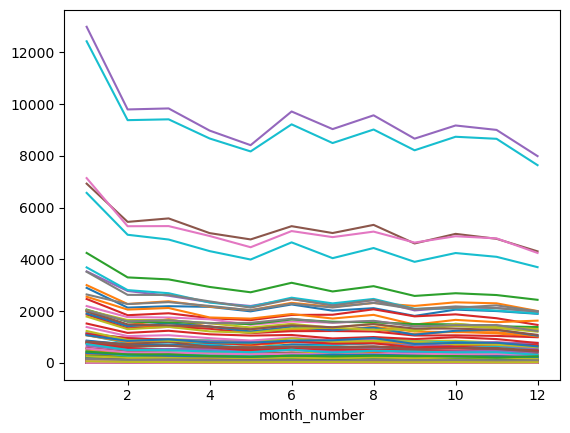

In [4]:
# plotting the line chart
pivot_table.plot(kind='line')
plt.legend().remove()
plt.show()

# its so messy

In [5]:
# lets add a total row
pivot_table.loc['Total'] = pivot_table.sum()

# sort by Total row
pivot_table = pivot_table[pivot_table.loc['Total'].sort_values(ascending=False).index]

# drop total row
pivot_table = pivot_table.drop('Total')

# keep only top 5 skill columns
pivot_table = pivot_table.iloc[:, :5]

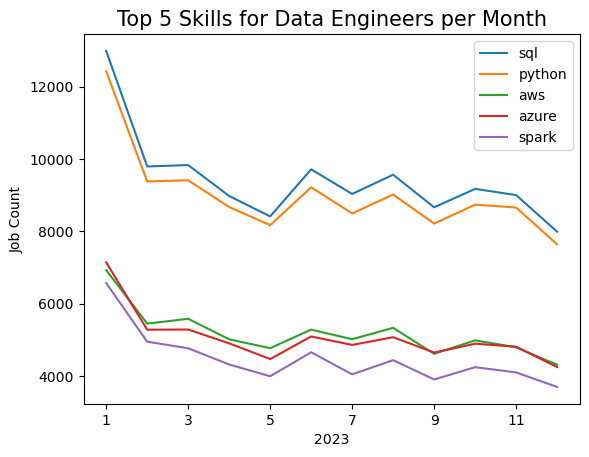

In [6]:
# final plotting with month name istead of month number
pivot_table.plot(kind='line')

# formatting
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.title('Top 5 Skills for Data Engineers per Month', fontsize=15)
plt.legend(title='')
plt.show()